# Creando una instancia de **ElasticSearch** en Cloud

Google Cloud trae un montón de soluciones ya preparadas, como por ejemplo:


*   Clusters para computación distribuida en la nube con Dataproc
*   Hadoop preinstalado en los clusters Dataproc
*   Instancias de diferentes bases de datos como BigQuery, MongoBD y otras
*   Capacidades de almacenamiento y gestión de datos en Storage de facil configuración
*   Containers de Kubernetes, en este módulo no alcanzamos a verlos :(
*   Soluciones de inteligencia computacional (o inteligencia artificial), como Vertex AI y otras
*   Y una infinidad de soluciones y posibilidades facilmente configurables...

Pero, por supuesto, no pueden estar todas las herramientas existentes ya preconfiguradas. La buena noticia es que si la solución que queremos no se ofrece directamente en Google Cloud, siempre podremos crear máquinas directamente e instalar y configurar según nuestra necesidad.

Un poco más complejo, pero nada imposible... 😀



# Vamos a crear un **nodo de ElasticSearch** con **Kibana** en Google Cloud!

Lo primero que tenemos que hacer es crear una máquina virtual, en la que realizaremos la instalación (Esto ya lo hemos hecho).

1-  Vamos a **Cloud Compute** y **creamos una instancia**:

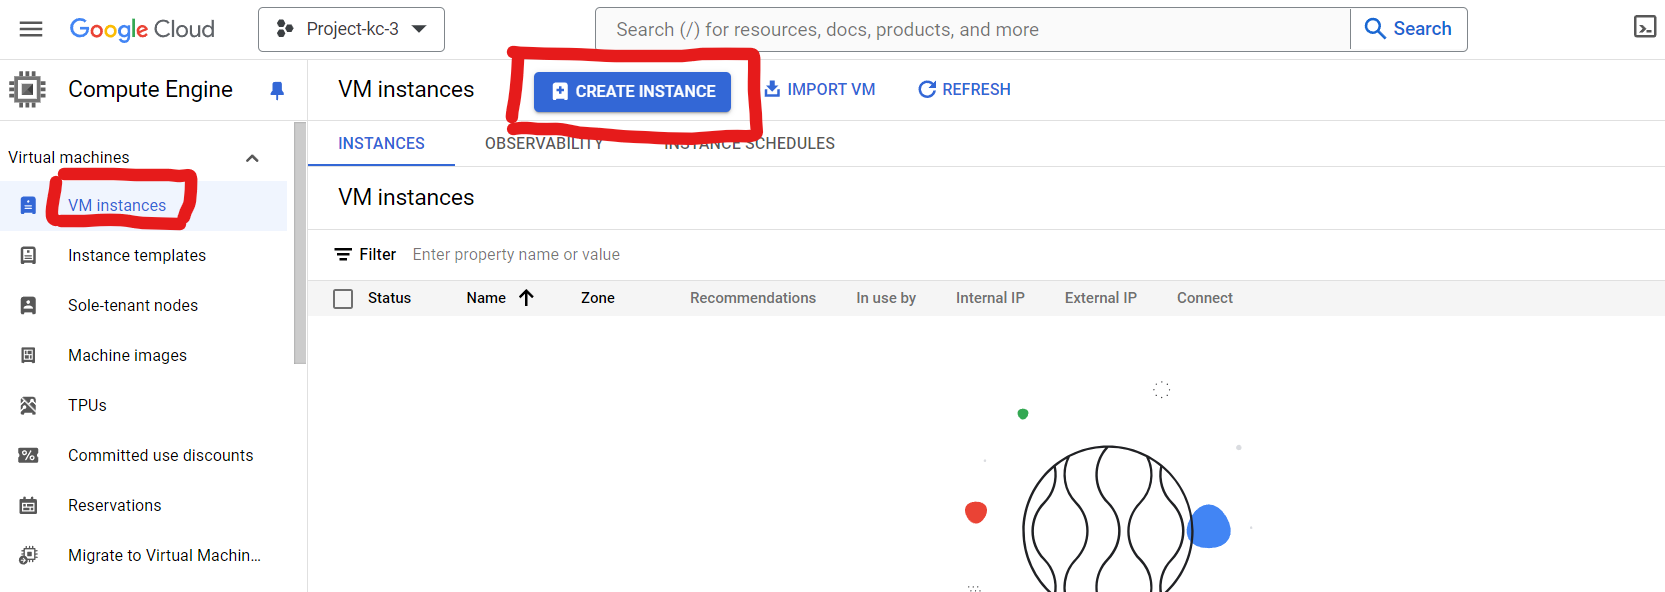


Tenemos que rellenar los datos con la configuración que queremos de la máquina.
ElasticSearch requiere recursos, por lo que debemos asegurarnos de darle suficiente RAM. (Con 4GB puede ser suficiente).

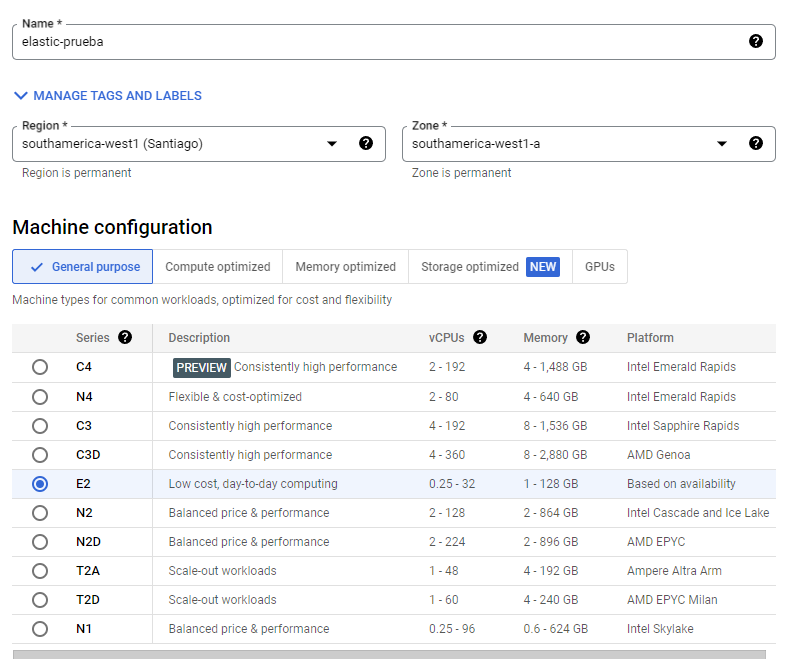

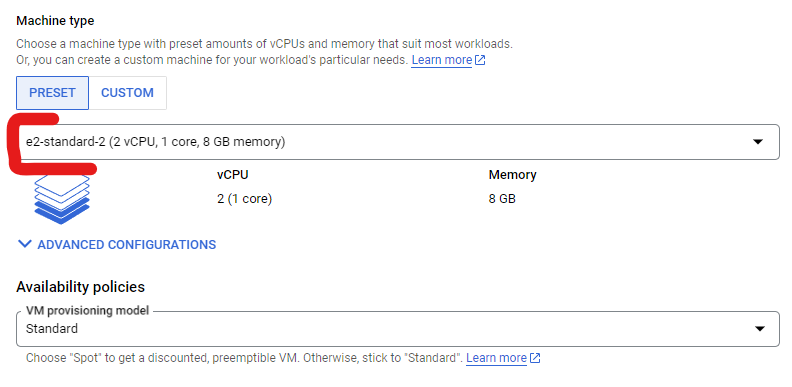

No olvidemos seleccionar las opciones para permitir tráfico HTTP y HTTPS:

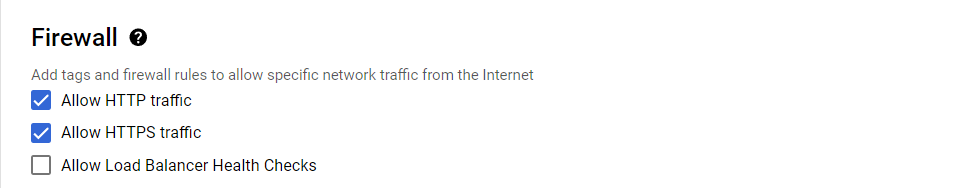

2- Una vez configurada y creada la instancia, vamos a **entrar por SSH a la máquina**

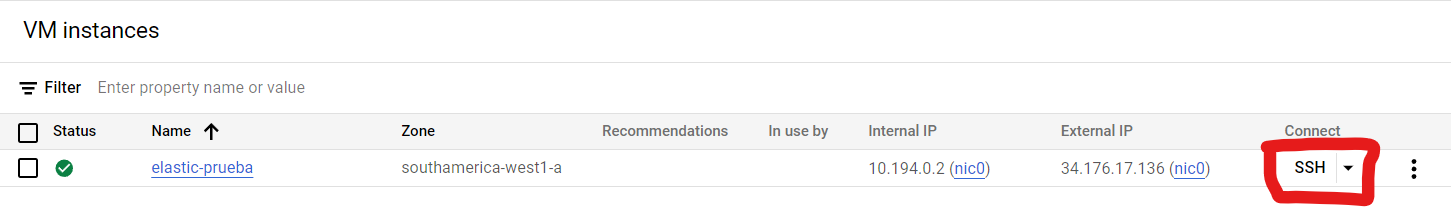



3- Cuando ya estemos **dentro de la máquina**, podremos proceder a descargar e instalar **ElasticSearch** y **Kibana**.

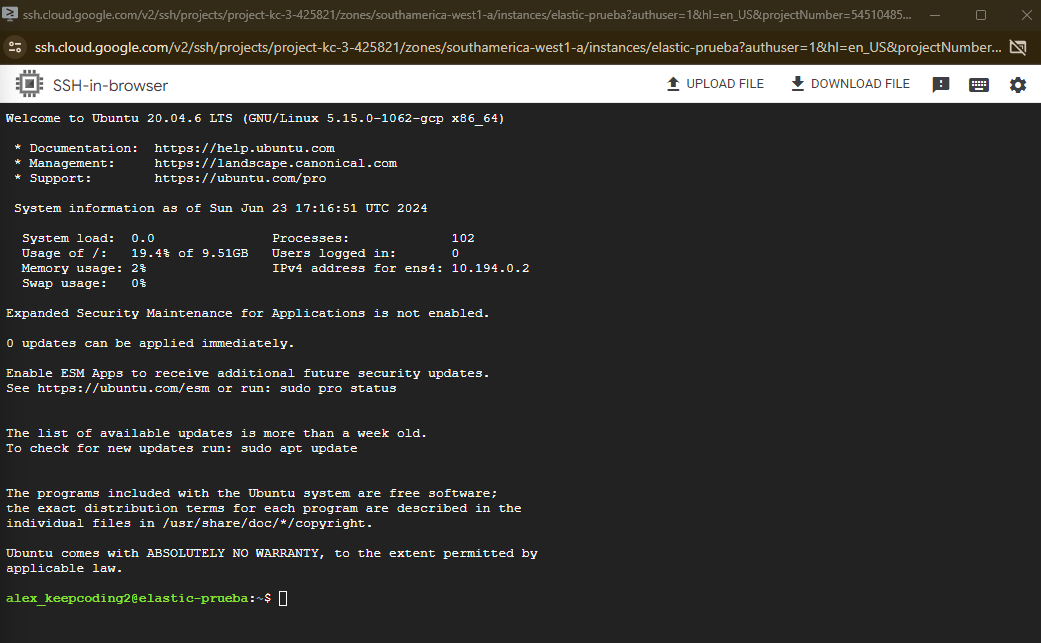

Primero, instalaremos wget, que nos permitirá descargar cualquier instalable (lanzaremos los comandos como administrador):

```bash
sudo apt install wget
```

Ahora vamos a descargar las ultimas versiones de elastic y kibana:

```bash
wget https://artifacts.elastic.co/downloads/elasticsearch/elasticsearch-8.14.1-amd64.deb
wget https://artifacts.elastic.co/downloads/kibana/kibana-8.14.1-amd64.deb
```

Y procedemos a instalar ambos:

```bash
sudo dpkg -i elasticsearch-8.14.1-amd64.deb
```

```bash
sudo dpkg -i kibana-8.14.1-amd64.deb
```

**ATENCIÓN!** Si trabajamos con versiones anteriores a *Elasticsearch 8*, debemos hacer la siguiente linea. Para Elasticsearch >=8, ya viene incluida esta configuración:
 onfiguramos `ElasticSearch` para que no solo acepte conexiones locales, sino desde cualquier IP:

👇👇👇 **SOLO ELASTICSEARCH < 8** 👇👇👇
```bash
sudo sed -i -e '$ahttp.host: 0.0.0.0' /etc/elasticsearch/elasticsearch.yml
sudo cat /etc/elasticsearch/elasticsearch.yml
```
👆👆👆 **SOLO ELASTICSEARCH < 8** 👆👆👆

Aqui lo que estamos haciendo es:

    *   sed: Es un editor de secuencias para realizar transformaciones en un flujo de texto
        *   -i: Edita el archivo
        *   -e: Permite añadir la siguiente expresión de edición al script
        *   '$ahttp.host: 0.0.0.0': Añade la linea 'http.host: 0.0.0.0' al final del archivo. '$' indica el final del archivo. 'a' indica añadir.
        *   /etc/elasticsearch/elasticsearch.yml: Es el archivo de configuración de ElasticSearch a editar.
    * Con el segundo comando, cat simplemente estamos mostrando el contenido del fichero.


Ahora repetimos la jugada y configuramos `kibana`. en este caso, sí hay que incluir esta configuración para Kibana, independiente de la versión:  

```bash
sudo sed -i -e '$aserver.host: 0.0.0.0' /etc/kibana/kibana.yml
sudo cat /etc/kibana/kibana.yml
```
Ahora sí hay una configuración que debemos cambiar en elastic:

```bash
sudo nano /etc/elasticsearch/elasticsearch.yml
```

Y colocamos estas variables a **false**:

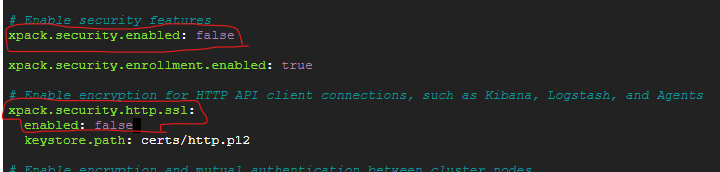

Finalmente, arrancamos (reiniciamos) tanto **ElasticSearch** como **Kibana**:

```bash
sudo service elasticsearch restart
sudo service kibana restart
```


## Paréntesis

Si hubiera algún problema en estos archivos de configuración y el servicio no se reiniciara correctamente, podemos hacer varias cosas:

a)

```bash
journalctl -xe
```

Se trata de un comando que nos mostrará un log donde veremos cualquier error o problema en la ejecución y una explicación del mismo.

b)

```bash
sudo cat /etc/elasticsearch/elasticsearch.yml
```
Así accederemos al fichero que tiene el problema, en este ejemplo, '/etc/elasticsearch/elasticsearch.yml' para poder hacer una revisión visual.

Si no hay ningún problema, seguimos adelante.

# Ya tenemos la configuración lista!

Ahora vamos a hacer **algunas pruebas**, con algunas llamadas desde este notebook. ¿A alguien se le ocurre qué necesitamos para poder hacer eso? 🤔

Configurar la regla de firewall!

In [2]:
!curl ipecho.net/plain

34.80.112.10

Recordad, el **puerto** por el que escucha **ElasticSearch** es el **9200**.

El puerto por el que escucha **Kibana**, el **5601**.

Si todo ha ido bien, despues de crear las reglas de firewall correspondientes podriamos ir a la siguiente url y ver un resultado:

http://IP_DE_LA_INSTANCIA_DE_ELASTIC:9200



Una vez que todo está ok...

# Vamos a **cargar** datos de ejemplo en **ElasticSearch**

Una vez que contamos con un server de elasticsearch podemos cargar datos de prueba para el siguiente ejercicio utilizando **Python** y el **API REST de elasticsearch**.

**Lo primero que vamos a necesitar es tener un bucket** desde el que poder cargar los datos, así que creémos un bucket nuevo.

Una vez creado, vamosa autenticarnos y configurar las variables en nuestro código, para poder acceder desde el notebook al server de ElasticSearch.


In [3]:
# Authenticate

from google.colab import auth
auth.authenticate_user()

In [4]:
# Setup values

project_id = 'bd14-project' # Nombre del proyecto
bucket_name = 'bucket-elastic-1' # Nombre del bucket que acabamos de crear

In [5]:
# Verify values

print(project_id)
print(bucket_name)

print('https://console.cloud.google.com/storage/browser?project=' + project_id)

bd14-project
bucket-elastic-1
https://console.cloud.google.com/storage/browser?project=bd14-project


In [6]:
# Import libs
from googleapiclient.discovery import build
gcs_service = build('storage', 'v1')

Instalamos la librería con la API de Google para Python

In [7]:
!pip install google-api-python-client


Vamos a utilizar este ejemplo para nuestra prueba:

https://www.elastic.co/guide/en/kibana/6.8/tutorial-load-dataset.html

In [8]:
# ELASTIC IP:
server_ip = 'http://35.238.251.163:9200'

Vamos a chequear que todo está ok con la conexión con el siguiente comando:

In [10]:
!curl -X GET "http://35.238.251.163:9200"

{
  "name" : "elastic-1",
  "cluster_name" : "elasticsearch",
  "cluster_uuid" : "fNJXS-1UQZeWSzq61ewiOQ",
  "version" : {
    "number" : "8.14.1",
    "build_flavor" : "default",
    "build_type" : "deb",
    "build_hash" : "93a57a1a76f556d8aee6a90d1a95b06187501310",
    "build_date" : "2024-06-10T23:35:17.114581191Z",
    "build_snapshot" : false,
    "lucene_version" : "9.10.0",
    "minimum_wire_compatibility_version" : "7.17.0",
    "minimum_index_compatibility_version" : "7.0.0"
  },
  "tagline" : "You Know, for Search"
}


Debería devolvernos lo mismo que vimos cuando introdujimos la IP en el navegador.

Si todo está bien, ahora vamos a enviar una solicitud PUT al servidor Elasticsearch para crear un índice que se llame "Shakespeare" con un mapeo específico que veremos acontinuación:

In [11]:
# Create index shakespeare with mappings:

import requests
import json
# Generamos la solicitud con request
# Vamos a crear un índice llamado Shakespeare con el formato de mapeo que indicamos en la variable json
result = requests.put(
    '{}/shakespeare'.format(server_ip),
    json={
      "mappings": {
        "properties": {
          "speaker": {"type": "keyword"},
          "play_name": {"type": "keyword"},
          "line_id": {"type": "integer"},
          "speech_number": {"type": "integer"}
        }
      }
    },
    headers={'Content-Type': 'application/json'},
)
print(result.text)

{"acknowledged":true,"shards_acknowledged":true,"index":"shakespeare"}


Ahora vamos a enviar una solicitud GET para obtener la información sobre el índice "Shakespeare", es decir, vamos a pedirle que nos devuelva ese índice y, de ese modo, comprobaremos si efectivamente se ha creado:

In [12]:
import requests

# La solicitud debe incluir la autenticación que hicimos más arriba
response = requests.get('{}/shakespeare'.format(server_ip)).json()

response

{'shakespeare': {'aliases': {},
  'mappings': {'properties': {'line_id': {'type': 'integer'},
    'play_name': {'type': 'keyword'},
    'speaker': {'type': 'keyword'},
    'speech_number': {'type': 'integer'}}},
  'settings': {'index': {'routing': {'allocation': {'include': {'_tier_preference': 'data_content'}}},
    'number_of_shards': '1',
    'provided_name': 'shakespeare',
    'creation_date': '1729710285854',
    'number_of_replicas': '1',
    'uuid': '9uIqzzp9Tem7XAHf91u1ng',
    'version': {'created': '8505000'}}}}}

## Ahora vamos a cargar data en nuestro índice "Shakespeare".

Para ello, primero instalaremos la librería Elasticsearch para Python:

In [13]:
!pip install elasticsearch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 524.6/524.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.5 MB/s eta 0:00:00


Ahora vamos a **subir nuestro archivo** de pruebas al bucket:

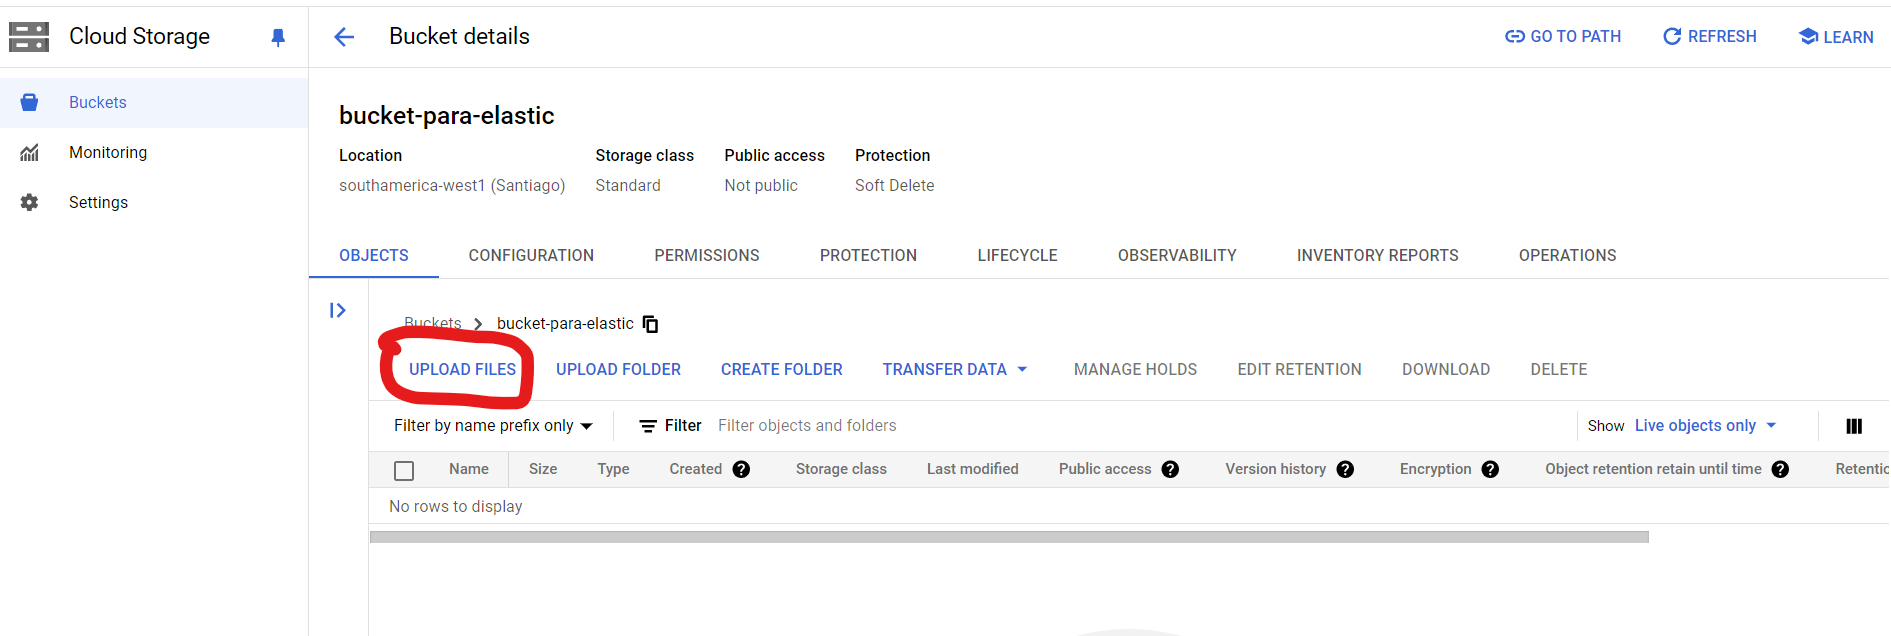


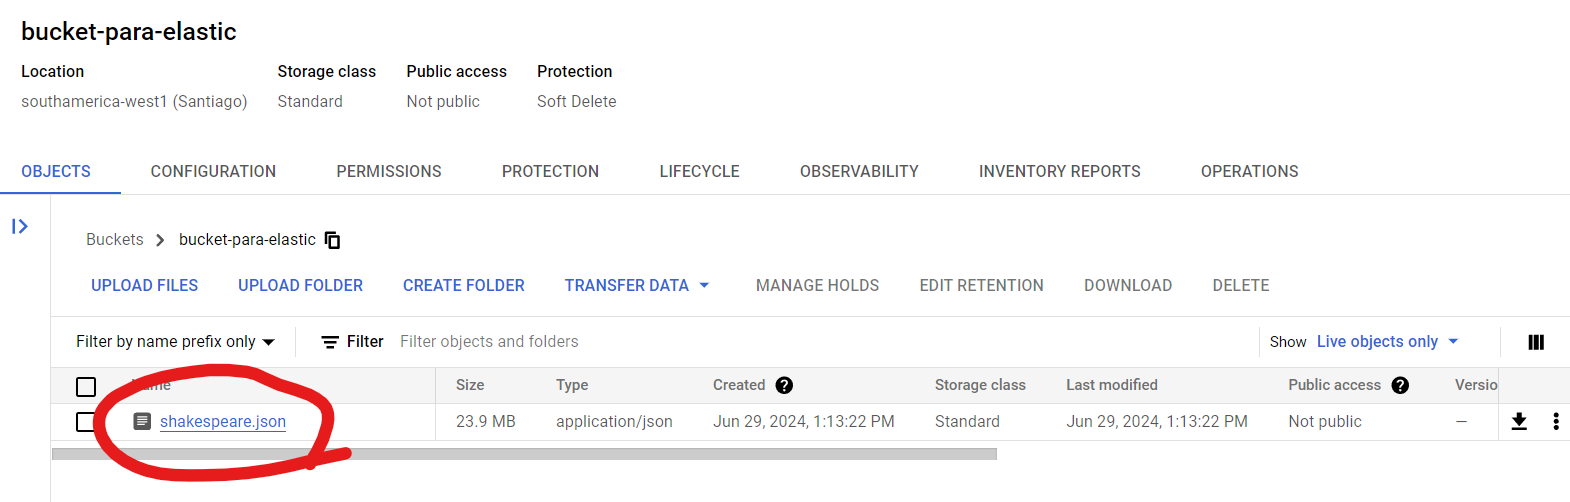

### Una vez subido, ya podemos **importarlo a elastic**.

Para esto, tenemos que **descargar** el fichero **desde el bucket, a nuestro Colab.**

Vamos a crear una función para eso:


In [14]:
# Download Function
from googleapiclient.http import MediaIoBaseDownload

def download_from_google_storage(bucket_name, remote_file, local_file):
  """
    Descarga un archivo desde Google Cloud Storage y lo guarda localmente.

    Args:
        bucket_name (str): El nombre del bucket en Google Cloud Storage.
        object (str): El nombre del objeto (archivo) que deseas descargar.
        local_file (str): La ruta y nombre del archivo local donde se guardará el contenido descargado.

    Returns:
        None
  """
  with open(local_file, 'wb') as f:
    # Creamos una solicitud (request) para obtener el contenido del objeto object
    request = gcs_service.objects().get_media(bucket=bucket_name, object=remote_file)
    # Inicializamos el objeto de descarga. f es el fichero local donde se escribirá el contenido
    media = MediaIoBaseDownload(f, request)

    done = False
    while not done:
      # _ es un placeholder (la función next_chunk devuelve dos valores, pero no nos interesa el primero)
      _, done = media.next_chunk()

  print('Download complete')

In [15]:
bucket_name = 'bucket-elastic-1'
local_file_name = 'shakespeare.json'
remote_file_name = 'shakespeare.json'

download_from_google_storage(bucket_name=bucket_name, remote_file=remote_file_name, local_file=local_file_name)

Download complete


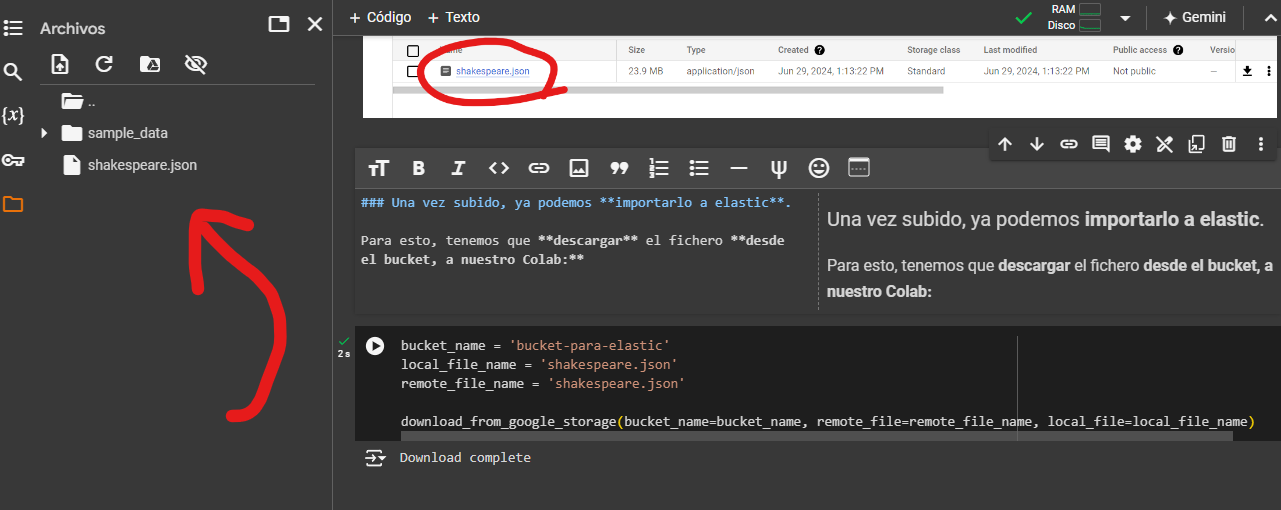

Echemos un vistazo al archivo:

In [16]:
!tail /content/shakespeare.json

{"index":{"_index":"shakespeare","_id":111391}}
{"type":"line","line_id":111392,"play_name":"A Winters Tale","speech_number":38,"line_number":"5.3.180","speaker":"LEONTES","text_entry":"Lead us from hence, where we may leisurely"}
{"index":{"_index":"shakespeare","_id":111392}}
{"type":"line","line_id":111393,"play_name":"A Winters Tale","speech_number":38,"line_number":"5.3.181","speaker":"LEONTES","text_entry":"Each one demand an answer to his part"}
{"index":{"_index":"shakespeare","_id":111393}}
{"type":"line","line_id":111394,"play_name":"A Winters Tale","speech_number":38,"line_number":"5.3.182","speaker":"LEONTES","text_entry":"Performd in this wide gap of time since first"}
{"index":{"_index":"shakespeare","_id":111394}}
{"type":"line","line_id":111395,"play_name":"A Winters Tale","speech_number":38,"line_number":"5.3.183","speaker":"LEONTES","text_entry":"We were disseverd: hastily lead away."}
{"index":{"_index":"shakespeare","_id":111395}}
{"type":"line","line_id":111396,"pl

Ahora, vamos a subir el fichero a nuestro índice "Shakespeare"

In [18]:
# Usaremos la librería elasticsearch, por simplicidad
from elasticsearch import Elasticsearch

colab_file_name = "/content/shakespeare.json"

# Inicializamos el cliente ElasticSearch
es = Elasticsearch(server_ip)

# Abrimos el fichero en modo r (lectura) para cargarlo
with open(colab_file_name, 'r') as f:
  data = f.read()
  # Enviamos los datos a Elasticsearch, al índice Shakespeare
  es.bulk(operations=data, index='shakespeare', timeout="10s")

Una vez subido, vamos a comprobar que efectivamente se ha cargado correctamente. Haremos una solicitud GET para obtener el contenido del índice "Shakespeare":

In [19]:
requests.get('{}/shakespeare/{}'.format(server_ip, '_search?pretty=true&q=*:*')).json()

{'took': 2668,
 'timed_out': False,
 '_shards': {'total': 1, 'successful': 1, 'skipped': 0, 'failed': 0},
 'hits': {'total': {'value': 10000, 'relation': 'gte'},
  'max_score': 1.0,
  'hits': [{'_index': 'shakespeare',
    '_id': '0',
    '_score': 1.0,
    '_source': {'type': 'act',
     'line_id': 1,
     'play_name': 'Henry IV',
     'speech_number': '',
     'line_number': '',
     'speaker': '',
     'text_entry': 'ACT I'}},
   {'_index': 'shakespeare',
    '_id': '1',
    '_score': 1.0,
    '_source': {'type': 'scene',
     'line_id': 2,
     'play_name': 'Henry IV',
     'speech_number': '',
     'line_number': '',
     'speaker': '',
     'text_entry': 'SCENE I. London. The palace.'}},
   {'_index': 'shakespeare',
    '_id': '2',
    '_score': 1.0,
    '_source': {'type': 'line',
     'line_id': 3,
     'play_name': 'Henry IV',
     'speech_number': '',
     'line_number': '',
     'speaker': '',
     'text_entry': 'Enter KING HENRY, LORD JOHN OF LANCASTER, the EARL of WESTMORE

**Ahí está! Enhorabuena!**

Si todo ha ido bien, hemos logrado cargar toda la obra de Shakespeare en un nodo de Elasticsearch en la nube, que has configurado tú mism@!





En este notebook hemos hecho muchas cosas!


*   Creamos un server de Elasticsearch. Y para ello:
  *   Tuvimos que crear una VM
  *   Instalar ElasticSearch
  *   Instalar Kibana (que la usaremos en el siguiente notebook)
  *   Configurar Firewall
*   Crear un bucket y subirle el contenido
*   Creamos un índice en nuestro server Elastic
*   Subimos contenido y lo descargamos, mediante solicitudes PUT y GET
*   Revisamos el contenido subido, y vimos que todo está OK!